# dunnhumby Deep Dive — Step 2A

## Goal
Take the raw dunnhumby data and produce a clean, modeling-ready dataset of perishable grocery transactions with proper time features.

## Why this notebook exists
dunnhumby is the heart of FreshFlow's forecasting model. Before any modeling, we need to:
1. Understand what's in the data
2. Filter down to genuinely perishable products
3. Convert the obfuscated DAY integers into real calendar dates
4. Save a clean interim dataset that downstream notebooks can load directly

## Inputs
- `data/raw/dunnhumby/transaction_data.csv` — 2.59M transaction rows
- `data/raw/dunnhumby/product.csv` — 92,353 product master records
- `data/raw/dunnhumby/hh_demographic.csv` — 801 household demographics

## Outputs
- `data/interim/products_classified.parquet` — enriched product master with perishable flags
- `data/interim/perishable_products.parquet` — perishables only (filtered subset)
- `data/interim/transactions_perishable.parquet` — clean perishable transactions with time features and categories


## Setup and paths

Standard imports and project paths.

**Why `Path` instead of strings:** `Path` is OS-agnostic (works on Mac, Linux, Windows). String paths break the moment you share the notebook with someone on a different OS.

**Why `DATA_INTERIM.mkdir(parents=True, exist_ok=True)`:** Creates the interim folder if it doesn't exist, doesn't error if it already does. Idempotent.

**Sanity check:** Confirms paths resolve correctly and lists the raw data files. If this cell prints empty file lists, paths are wrong — fix before continuing.


In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Project paths — adjust if your structure is different
PROJECT_ROOT = Path("../..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dunnhumby"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

print(f"Project root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_RAW}")
print(f"Files found: {[f.name for f in DATA_RAW.glob('*.csv')]}")

Project root: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system
Looking for data in: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/raw/dunnhumby
Files found: ['hh_demographic.csv', 'causal_data.csv', 'coupon.csv', 'campaign_table.csv', 'coupon_redempt.csv', 'product.csv', 'campaign_desc.csv', 'transaction_data.csv']


## Load all dunnhumby tables and get scale

Load transactions, products, and households. Print scale numbers.

**What to look for:**
- Transaction count tells us modeling sample size (2.59M = plenty)
- DAY range (1 to 711) tells us the time span (~711 days, ~2 years)
- Household count tells us breadth (2,500 households — reasonable for behavioral patterns)
- Store count (582) tells us we have multi-store data — useful for hierarchical modeling
- Product count (92,339) tells us SKU breadth

**Note:** Only 801 of 2,500 households have demographic data. That's normal — demographics are opt-in. Don't try to demographic-segment when modeling, only ~32% of households are covered.


In [34]:
# Load all dunnhumby tables
transactions = pd.read_csv(DATA_RAW / "transaction_data.csv")
products = pd.read_csv(DATA_RAW / "product.csv")
households = pd.read_csv(DATA_RAW / "hh_demographic.csv")

print("=" * 60)
print("DUNNHUMBY DATA OVERVIEW")
print("=" * 60)
print(f"\nTransactions: {transactions.shape[0]:,} rows, {transactions.shape[1]} columns")
print(f"Products:     {products.shape[0]:,} SKUs")
print(f"Households:   {households.shape[0]:,} households with demographics")

print(f"\nTransactions date range (DAY column): {transactions['DAY'].min()} to {transactions['DAY'].max()}")
print(f"Total days covered: {transactions['DAY'].max() - transactions['DAY'].min() + 1}")
print(f"Unique households in transactions: {transactions['household_key'].nunique():,}")
print(f"Unique stores: {transactions['STORE_ID'].nunique():,}")
print(f"Unique products: {transactions['PRODUCT_ID'].nunique():,}")

DUNNHUMBY DATA OVERVIEW

Transactions: 2,595,732 rows, 12 columns
Products:     92,353 SKUs
Households:   801 households with demographics

Transactions date range (DAY column): 1 to 711
Total days covered: 711
Unique households in transactions: 2,500
Unique stores: 582
Unique products: 92,339


## Understand the departments

Print all departments and their SKU counts.

**Why this matters:** dunnhumby organizes products by department. Before classifying perishables, we need to know what departments exist and how big they are.

**Key finding:** GROCERY (39,021 SKUs) and DRUG GM (31,529 SKUs) dominate. These are shelf-stable groceries and drug/general merchandise — NOT perishable. But true perishables (PRODUCE, MEAT, etc.) are smaller, named departments.

**Trap to avoid:** Don't assume DEPARTMENT alone tells you what's perishable. We'll see in later cells that real dairy is misclassified into GROCERY.


In [35]:
# What departments exist?
dept_counts = products["DEPARTMENT"].value_counts()
print("All departments and SKU counts:")
print(dept_counts.to_string())
print(f"\nTotal SKUs: {len(products):,}")

All departments and SKU counts:
DEPARTMENT
GROCERY            39021
DRUG GM            31529
PRODUCE             3118
COSMETICS           3011
NUTRITION           2914
MEAT                2544
MEAT-PCKGD          2427
DELI                2354
PASTRY              2149
FLORAL               938
SEAFOOD-PCKGD        563
MISC. TRANS.         490
SPIRITS              377
SEAFOOD              369
GARDEN CENTER        128
RESTAURANT           102
MISC SALES TRAN       88
SALAD BAR             48
COUP/STR & MFG        39
TRAVEL & LEISUR       28
FROZEN GROCERY        23
KIOSK-GAS             16
                      15
CHEF SHOPPE           14
RX                     9
CNTRL/STORE SUP        4
DAIRY DELI             3
TOYS                   3
POSTAL CENTER          3
GM MERCH EXP           3
VIDEO RENTAL           3
AUTOMOTIVE             2
PHOTO                  2
VIDEO                  2
PROD-WHS SALES         2
DELI/SNACK BAR         2
CHARITABLE CONT        2
GRO BAKERY             2
PORK   

## First-pass perishable filter (department-only)

Filter products to a list of "always perishable" departments.

**This is a first-pass filter, not the final one.** We use it to see the rough scale of perishables in the dataset.

**Expected result:** Around 14,000-16,000 perishable SKUs (15-20% of all SKUs).

**Why we won't stop here:** This filter has two known problems:
1. **Misses dairy** — most dairy products live in GROCERY department, not DAIRY DELI
2. **Includes shelf-stable items** — POPCORN sits in PRODUCE department but isn't perishable

later sections fix both problems.


In [36]:
# Define perishable departments
PERISHABLE_DEPARTMENTS = [
    "PRODUCE",
    "MEAT", "MEAT-PCKGD",
    "SEAFOOD", "SEAFOOD-PCKGD",
    "DELI", "DAIRY DELI",
    "PASTRY", "GRO BAKERY",
    "FLORAL",
    "SALAD BAR",
]

# Filter product master to perishables
perishable_products = products[products["DEPARTMENT"].isin(PERISHABLE_DEPARTMENTS)].copy()
print(f"Perishable SKUs: {len(perishable_products):,} out of {len(products):,} total ({len(perishable_products)/len(products)*100:.1f}%)")

print("\nPerishable SKU breakdown by department:")
print(perishable_products["DEPARTMENT"].value_counts().to_string())

print("\nSample perishable products:")
perishable_products.sample(10, random_state=42)

Perishable SKUs: 14,515 out of 92,353 total (15.7%)

Perishable SKU breakdown by department:
DEPARTMENT
PRODUCE          3118
MEAT             2544
MEAT-PCKGD       2427
DELI             2354
PASTRY           2149
FLORAL            938
SEAFOOD-PCKGD     563
SEAFOOD           369
SALAD BAR          48
DAIRY DELI          3
GRO BAKERY          2

Sample perishable products:


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
73120,10341947,6216,DELI,National,PREPARED FOOD,QSR FD: COLD PIZZA,
4589,577273,3592,DELI,National,SALADS/DIPS,PASTA/GRAIN SALADS - BULK,
8764,844641,3340,SEAFOOD,National,SEAFOOD-FRESH,SEAFOOD-FRE-RAW FINFISH-OTHER,
8797,844916,2940,MEAT,National,BEEF,CHOICE BEEF,
50860,2572127,5216,PASTRY,National,CAKES,CAKES: SHEET,24 OZ.
79299,12807251,665,MEAT-PCKGD,National,DINNER SAUSAGE,SMOKED/COOKED - BEEF,14 OZ
37343,1097917,5510,PASTRY,National,BAKERY PARTY TRAYS,PARTY TRAYS: COOKIES-ROLLS,28.5 OZ
54470,5592144,5423,MEAT-PCKGD,National,DINNER SAUSAGE,FRESH,18 OZ
53563,5574409,3492,MEAT,National,PORK,ENHANCED,
65129,9245315,848,PASTRY,National,BREAD,BREAD:LOAF/SNACK,30OZ


## Look at commodities within each perishable department

Drill one level deeper than DEPARTMENT to inspect what COMMODITY_DESC values exist.

**Why:** DEPARTMENT is too coarse. COMMODITY_DESC is the next level of product classification (e.g., department=PRODUCE, commodity=APPLES, sub-commodity=GALA APPLES).

**What to look for:**
- Real perishable commodities (BREAD, BEEF, APPLES, FRESH FISH)
- Shelf-stable commodities hiding in perishable departments (POPCORN in PRODUCE, BAKERY PARTY TRAYS in PASTRY)

**Decision driver:** This output tells us we need a finer filter than DEPARTMENT alone.


In [37]:
# Look at commodities WITHIN the perishable departments to see what's really there
print("Commodities within perishable departments:")
print("=" * 60)

for dept in PERISHABLE_DEPARTMENTS:
    dept_products = products[products["DEPARTMENT"] == dept]
    if len(dept_products) < 10:
        continue  # Skip near-empty departments
    print(f"\n--- {dept} ({len(dept_products)} SKUs) ---")
    top_commodities = dept_products["COMMODITY_DESC"].value_counts().head(15)
    print(top_commodities.to_string())

Commodities within perishable departments:

--- PRODUCE (3118 SKUs) ---
COMMODITY_DESC
PROCESSED                      319
ORGANICS FRUIT & VEGETABLES    308
SALAD MIX                      253
VEGETABLES - ALL OTHERS        203
POPCORN                        199
APPLES                         173
CITRUS                         154
POTATOES                       142
ONIONS                         117
NUTS                           112
BERRIES                        105
VALUE ADDED VEGETABLES          96
HERBS                           91
TOMATOES                        85
TROPICAL FRUIT                  81

--- MEAT (2544 SKUs) ---
COMMODITY_DESC
BEEF                       1109
PORK                        598
CHICKEN                     364
TURKEY                      185
SMOKED MEATS                181
LAMB                         53
VEAL                         22
EXOTIC GAME/FOWL             15
RW FRESH PROCESSED MEAT       5
(CORP USE ONLY)               4
MEAT SUPPLIES              

## Hunt for dairy hiding in the GROCERY department

Search GROCERY department for any product with dairy-related keywords (MILK, YOGURT, CHEESE, CREAM, EGG, BUTTER, DAIRY).

**Why this matters:** In real dunnhumby, true perishable dairy is mostly classified into GROCERY, not DAIRY DELI. If we don't recover these, we'd miss ~5,000 perishable SKUs.

**Expected result:** 4,000–6,000 dairy products in GROCERY.

**Trap to avoid:** Pure keyword matching gives false positives (e.g., "PEANUT BUTTER" contains BUTTER, "CANNED MILK" contains MILK but is shelf-stable). the classifier section will use the actual commodity descriptions (not keywords) to filter precisely.


In [38]:
# Dairy is probably misclassified into GROCERY. Let's find it.
grocery_products = products[products["DEPARTMENT"] == "GROCERY"]

# Search for dairy-related keywords in commodity descriptions
dairy_keywords = ["MILK", "YOGURT", "CHEESE", "CREAM", "EGG", "BUTTER", "DAIRY"]

dairy_in_grocery = grocery_products[
    grocery_products["COMMODITY_DESC"].str.contains("|".join(dairy_keywords), case=False, na=False) |
    grocery_products["SUB_COMMODITY_DESC"].str.contains("|".join(dairy_keywords), case=False, na=False)
]

print(f"Dairy products hiding in GROCERY department: {len(dairy_in_grocery):,}")
print(f"\nTop commodities found:")
print(dairy_in_grocery["COMMODITY_DESC"].value_counts().head(20).to_string())

print(f"\nSample dairy products in GROCERY:")
dairy_in_grocery.sample(10, random_state=42)

Dairy products hiding in GROCERY department: 5,080

Top commodities found:
COMMODITY_DESC
CHEESE                    1096
ICE CREAM/MILK/SHERBTS     815
YOGURT                     686
FLUID MILK PRODUCTS        455
REFRGRATD JUICES/DRNKS     391
MILK BY-PRODUCTS           288
CRACKERS/MISC BKD FD       255
MISC. DAIRY                246
PNT BTR/JELLY/JAMS         131
EGGS                       119
DINNER MXS:DRY              95
BAG SNACKS                  91
COFFEE                      67
SYRUPS/TOPPINGS             62
CANNED MILK                 55
BUTTER                      54
COCOA MIXES                 53
FRZN NOVELTIES/WTR ICE      52
FROZEN PIE/DESSERTS         39
DRY MIX DESSERTS            20

Sample dairy products in GROCERY:


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
42569,1195889,69,GROCERY,Private,REFRGRATD JUICES/DRNKS,DAIRY CASE 100% PURE JUICE - O,
56061,6392003,69,GROCERY,Private,ICE CREAM/MILK/SHERBTS,TRADITIONAL,56 OZ
190,32553,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,
19097,935393,1266,GROCERY,National,PNT BTR/JELLY/JAMS,PEANUT BUTTER,40 OZ
48655,1971373,69,GROCERY,Private,ICE CREAM/MILK/SHERBTS,TRADITIONAL,56 OZ
41849,1139058,317,GROCERY,National,MILK BY-PRODUCTS,COTTAGE CHEESE,5.5 OZ
62859,8121909,69,GROCERY,Private,CHEESE,NATURAL CHEESE EXACT WT CHUNKS,8 OZ
61145,7441652,69,GROCERY,Private,ICE CREAM/MILK/SHERBTS,PREMIUM,56 OZ
43915,1320712,1266,GROCERY,National,PNT BTR/JELLY/JAMS,PEANUT BUTTER,18 OZ
34842,1076088,857,GROCERY,National,PNT BTR/JELLY/JAMS,PEANUT BUTTER,10.5 OZ


## Placeholder (do not run)

This was a draft of the perishable classification function. The final version is in the classifier section.

You can leave this cell as-is or delete it — it's not part of the working pipeline.


## Build the corrected perishable classifier

Define explicit business rules for what counts as perishable, then apply them to the full product master.

**The three classification rules:**
1. **Always-perishable departments** — PRODUCE, MEAT, MEAT-PCKGD, SEAFOOD, SEAFOOD-PCKGD, DELI, SALAD BAR. Every SKU here is perishable.
2. **PASTRY (mixed)** — only items with BREAD, BAGEL, MUFFIN, DONUT, ROLL, PASTRY, or CROISSANT in their commodity name. Cookies and party trays don't qualify.
3. **GROCERY (dairy hiding)** — only specific commodities: CHEESE, YOGURT, FLUID MILK PRODUCTS, MILK BY-PRODUCTS, MISC. DAIRY, REFRGRATD JUICES/DRNKS, EGGS, BUTTER.

**Output:** Two new columns added to the products dataframe:
- `IS_PERISHABLE` (boolean)
- `PERISHABLE_CATEGORY` — normalized 6-category label: PRODUCE, MEAT, SEAFOOD, DELI, BAKERY, DAIRY

**Why constants at the top:** These lists encode business knowledge ("what is perishable"). Defining them as named constants at the top of the cell makes them easy to find, review, and change. Buried logic = bad. Named constants at the top = good.

**Why this isn't "hardcoding" in the bad sense:** These are domain assumptions, not magic numbers. They'll move to `configs/perishable_classification.yaml` once we finish exploring.


In [39]:
# True perishable commodities from GROCERY department (curated from actual data)
DAIRY_PERISHABLE_COMMODITIES = [
    "CHEESE",
    "YOGURT",
    "FLUID MILK PRODUCTS",
    "MILK BY-PRODUCTS",
    "MISC. DAIRY",
    "REFRGRATD JUICES/DRNKS",
    "EGGS",
    "BUTTER",
]

# PASTRY: separate the truly fresh items from cookies/party trays
PASTRY_PERISHABLE_KEYWORDS = ["BREAD", "BAGEL", "MUFFIN", "DONUT", "ROLL", "PASTRY", "CROISSANT"]

# Always-perishable departments
ALWAYS_PERISHABLE_DEPTS = [
    "PRODUCE",
    "MEAT", "MEAT-PCKGD",
    "SEAFOOD", "SEAFOOD-PCKGD",
    "DELI",
    "SALAD BAR",
]


def classify_perishable(row):
    """
    Classify a product as perishable or not.
    Uses both DEPARTMENT and COMMODITY_DESC for accuracy.
    Returns True if perishable (fresh, short shelf life).
    """
    dept = row["DEPARTMENT"]
    commodity = str(row["COMMODITY_DESC"]).upper()

    # Always-perishable departments
    if dept in ALWAYS_PERISHABLE_DEPTS:
        return True

    # PASTRY: only fresh items, not cookies/cakes/party trays
    if dept == "PASTRY":
        return any(kw in commodity for kw in PASTRY_PERISHABLE_KEYWORDS)

    # GROCERY: only true perishable dairy commodities
    if dept == "GROCERY":
        return commodity in DAIRY_PERISHABLE_COMMODITIES

    return False


# Apply classification
products["IS_PERISHABLE"] = products.apply(classify_perishable, axis=1)

# Assign a perishable category for later modeling
def assign_perishable_category(row):
    if not row["IS_PERISHABLE"]:
        return None
    dept = row["DEPARTMENT"]
    commodity = str(row["COMMODITY_DESC"]).upper()

    if dept == "PRODUCE":
        return "PRODUCE"
    if dept in ["MEAT", "MEAT-PCKGD"]:
        return "MEAT"
    if dept in ["SEAFOOD", "SEAFOOD-PCKGD"]:
        return "SEAFOOD"
    if dept == "DELI" or dept == "SALAD BAR":
        return "DELI"
    if dept == "PASTRY":
        return "BAKERY"
    if dept == "GROCERY":  # dairy hiding in grocery
        return "DAIRY"
    return None

products["PERISHABLE_CATEGORY"] = products.apply(assign_perishable_category, axis=1)

# Now look at the cleaned result
perishable_products = products[products["IS_PERISHABLE"]].copy()
print(f"Total perishable SKUs: {len(perishable_products):,} ({len(perishable_products)/len(products)*100:.1f}% of all SKUs)")
print(f"\nBy perishable category:")
print(perishable_products["PERISHABLE_CATEGORY"].value_counts().to_string())
print(f"\nSample perishables across categories:")
perishable_products.groupby("PERISHABLE_CATEGORY").apply(lambda x: x.sample(min(3, len(x)), random_state=42)).reset_index(drop=True)

Total perishable SKUs: 15,316 (16.6% of all SKUs)

By perishable category:
PERISHABLE_CATEGORY
MEAT       4971
DAIRY      3338
PRODUCE    3118
DELI       2402
SEAFOOD     932
BAKERY      555

Sample perishables across categories:


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,IS_PERISHABLE,PERISHABLE_CATEGORY
0,1271207,5944,PASTRY,National,BREAD,BREAD:LOAF/SNACK,21.5 OZ,True,BAKERY
1,9368175,5423,PASTRY,National,BREAD,BREAD:LOAF/SNACK,16 OZ,True,BAKERY
2,850004,5324,PASTRY,National,BREAD,BREAD:SAVORY/SPECIALTY,,True,BAKERY
3,1426851,69,GROCERY,Private,CHEESE,NATURAL CHEESE EXACT WT CHUNKS,8 OZ,True,DAIRY
4,13006898,435,GROCERY,National,MISC. DAIRY,REFRIGERATED PASTA,20 OZ,True,DAIRY
5,893739,1487,GROCERY,National,YOGURT,YOGURT NOT MULTI-PACKS,6 OZ,True,DAIRY
6,990999,4487,DELI,National,DELI MEATS,MEAT: TURKEY BULK,,True,DELI
7,599939,4478,DELI,National,DELI MEATS,MEAT: CHICKEN BULK,,True,DELI
8,6555223,1025,DELI,National,CHEESES,CHEESE:SPECIALTY PREPACK,8 OZ,True,DELI
9,890401,3033,MEAT,National,PORK,LOIN - CHOPS BONE-IN,,True,MEAT


## Eyeball check the classification

Random sample 5 products from each perishable category. Manually verify each one makes sense.

**The DS judgment call:** No automated test can tell you "is microwave popcorn perishable." A human looks at the sample and decides.

**What we found in this sample:**
- BAKERY: bread, rolls — ✅ perishable
- DAIRY: cheese, yogurt, milk — ✅ perishable
- DELI: deli meats, salads, cheeses — ✅ perishable
- MEAT: pork chops, hot dogs, ground beef — ✅ perishable
- PRODUCE: contains POPCORN ❌ (shelf-stable, needs fixing)
- SEAFOOD: contains FROZEN SHRIMP ❌ (wrong shelf-life category, needs fixing)

**Action:** the refinement pass add a refinement pass to remove POPCORN, NUTS, and FROZEN items.


In [40]:
# Random sample to eyeball check the classification
print("Random sample across categories — do these look perishable to you?")
print("=" * 70)
for cat in sorted(perishable_products["PERISHABLE_CATEGORY"].dropna().unique()):
    print(f"\n--- {cat} ---")
    sample = perishable_products[perishable_products["PERISHABLE_CATEGORY"] == cat].sample(5, random_state=42)
    print(sample[["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "CURR_SIZE_OF_PRODUCT"]].to_string(index=False))

Random sample across categories — do these look perishable to you?

--- BAKERY ---
DEPARTMENT COMMODITY_DESC     SUB_COMMODITY_DESC CURR_SIZE_OF_PRODUCT
    PASTRY          BREAD       BREAD:LOAF/SNACK              21.5 OZ
    PASTRY          BREAD       BREAD:LOAF/SNACK                16 OZ
    PASTRY          BREAD BREAD:SAVORY/SPECIALTY                     
    PASTRY          ROLLS        ROLLS: SANDWICH                     
    PASTRY          BREAD   BREAD:ITALIAN/FRENCH                     

--- DAIRY ---
DEPARTMENT      COMMODITY_DESC             SUB_COMMODITY_DESC CURR_SIZE_OF_PRODUCT
   GROCERY              CHEESE NATURAL CHEESE EXACT WT CHUNKS                 8 OZ
   GROCERY         MISC. DAIRY             REFRIGERATED PASTA                20 OZ
   GROCERY              YOGURT         YOGURT NOT MULTI-PACKS                 6 OZ
   GROCERY              YOGURT         YOGURT NOT MULTI-PACKS                 6 OZ
   GROCERY FLUID MILK PRODUCTS   REFRIGERATED COFFEE CREAMERS      

## Save the initial classified product master

Save two interim files in Parquet format:
- `products_classified.parquet` — full product master with perishable flags
- `perishable_products.parquet` — perishables subset only

**Why Parquet, not CSV:**
- ~10× smaller files (columnar compression)
- Preserves data types (CSV loses everything as strings)
- ~5× faster to read back than CSV
- Standard format in real DS pipelines

**Note:** This file gets overwritten in the final save step after the refinement pass. The save here is a checkpoint in case the refinement breaks something — we can roll back.


In [41]:
# Save the enriched product master with perishable flags
output_path = DATA_INTERIM / "products_classified.parquet"
products.to_parquet(output_path, index=False)
print(f"Saved enriched product master: {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")

# Also save just the perishables as a separate file
perishables_path = DATA_INTERIM / "perishable_products.parquet"
perishable_products.to_parquet(perishables_path, index=False)
print(f"Saved perishable products only: {perishables_path}")
print(f"File size: {perishables_path.stat().st_size / 1e6:.1f} MB")

Saved enriched product master: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/products_classified.parquet
File size: 1.3 MB
Saved perishable products only: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/perishable_products.parquet
File size: 0.2 MB


## Refine: exclude shelf-stable items and frozen items

Apply a second-pass filter to remove false positives caught in the eyeball check.

**Two exclusion rules:**
1. **Excluded commodities** — POPCORN and NUTS sit in PRODUCE but are shelf-stable (months of shelf life). Remove them.
2. **Frozen items** — Any product with FROZEN or FRZ in its commodity or sub-commodity name. Frozen goods have completely different waste dynamics (months of shelf life, freezer-failure failure mode) and don't belong in fresh-perishable modeling.

**Why this is a separate cell, not part of the classifier section:** It separates the "what is perishable" logic from the "what to exclude" logic. Easier to review and modify each independently. Also leaves an audit trail — anyone reading the notebook can see exactly what was filtered and why.

**Expected result:** Drops ~800–1,200 SKUs from ~15,300 down to ~14,100.


In [42]:
# Refinement: exclude shelf-stable items hiding in perishable departments
EXCLUDE_COMMODITIES = [
    "POPCORN",  # Microwave popcorn in PRODUCE — shelf-stable
    "NUTS",     # Bagged nuts in PRODUCE — shelf-stable (months)
]

# Refinement: exclude any commodity with FROZEN in the name
def is_frozen_item(row):
    commodity = str(row["COMMODITY_DESC"]).upper()
    sub_commodity = str(row["SUB_COMMODITY_DESC"]).upper()
    if "FROZEN" in commodity or "FROZEN" in sub_commodity:
        return True
    if "FRZ" in commodity or "FRZ" in sub_commodity:  # abbreviation used in dunnhumby
        return True
    return False


# Apply refinements
products["IS_FROZEN"] = products.apply(is_frozen_item, axis=1)
products["IS_EXCLUDED_COMMODITY"] = products["COMMODITY_DESC"].isin(EXCLUDE_COMMODITIES)

# Updated perishable flag
products["IS_PERISHABLE_V2"] = (
    products["IS_PERISHABLE"]
    & ~products["IS_FROZEN"]
    & ~products["IS_EXCLUDED_COMMODITY"]
)

# Show what changed
before = products["IS_PERISHABLE"].sum()
after = products["IS_PERISHABLE_V2"].sum()
removed = before - after

print(f"Perishables before refinement: {before:,}")
print(f"Perishables after refinement:  {after:,}")
print(f"Removed (frozen + shelf-stable false positives): {removed:,}")

# Breakdown of what was removed
removed_products = products[products["IS_PERISHABLE"] & ~products["IS_PERISHABLE_V2"]]
print(f"\nRemoval breakdown:")
print(f"  - Frozen items: {removed_products['IS_FROZEN'].sum():,}")
print(f"  - Excluded commodities (POPCORN, NUTS): {removed_products['IS_EXCLUDED_COMMODITY'].sum():,}")

Perishables before refinement: 15,316
Perishables after refinement:  14,148
Removed (frozen + shelf-stable false positives): 1,168

Removal breakdown:
  - Frozen items: 857
  - Excluded commodities (POPCORN, NUTS): 311


## Verify the refinement worked

Two assertions in code:
1. POPCORN count in final perishables should be 0
2. Any commodity containing FROZEN or FRZ should be 0

**Why this cell exists:** In real DS, you don't just trust that a filter worked — you verify with explicit checks. If either count is non-zero, the filter has a bug and we stop.

**Interview talking point:** This is what "test your data pipeline" looks like in practice. Most candidates don't do this. Senior DS hiring managers notice.


In [43]:
# Check: do POPCORN and FROZEN items still appear?
perishables_v2 = products[products["IS_PERISHABLE_V2"]].copy()

# Should return 0
popcorn_check = perishables_v2[perishables_v2["COMMODITY_DESC"] == "POPCORN"]
print(f"POPCORN still in perishables (should be 0): {len(popcorn_check)}")

# Should return 0
frozen_check = perishables_v2[
    perishables_v2["COMMODITY_DESC"].str.contains("FROZEN|FRZ", case=False, na=False)
]
print(f"FROZEN items still in perishables (should be 0): {len(frozen_check)}")

# Updated category breakdown
print(f"\nFinal perishable category breakdown:")
print(perishables_v2["PERISHABLE_CATEGORY"].value_counts().to_string())
print(f"\nTotal final perishable SKUs: {len(perishables_v2):,}")

POPCORN still in perishables (should be 0): 0
FROZEN items still in perishables (should be 0): 0

Final perishable category breakdown:
PERISHABLE_CATEGORY
MEAT       4617
DAIRY      3338
PRODUCE    2807
DELI       2402
BAKERY      555
SEAFOOD     429

Total final perishable SKUs: 14,148


## Final eyeball check across all categories

Random sample 5 products per category one more time, this time on the refined perishables.

**The question to ask each row:** "Would this product spoil within days to weeks?"

If yes for all rows → classification is good, proceed.
If any row looks wrong → flag it, refine the filter, re-run.

**This is the last human checkpoint** before we save the cleaned data and move to transaction filtering.


In [44]:
# Final eyeball check — random sample across each category
print("Final classification sample — check each row makes sense:")
print("=" * 80)
for cat in sorted(perishables_v2["PERISHABLE_CATEGORY"].dropna().unique()):
    print(f"\n--- {cat} ({(perishables_v2['PERISHABLE_CATEGORY'] == cat).sum()} SKUs) ---")
    sample = perishables_v2[perishables_v2["PERISHABLE_CATEGORY"] == cat].sample(5, random_state=123)
    print(sample[["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]].to_string(index=False))

Final classification sample — check each row makes sense:

--- BAKERY (555 SKUs) ---
DEPARTMENT COMMODITY_DESC            SUB_COMMODITY_DESC
    PASTRY          BREAD          BREAD:ITALIAN/FRENCH
    PASTRY          ROLLS ROLLS: CROISSANTS/BREADSTICKS
    PASTRY          BREAD            BREAD:PARTY BREADS
    PASTRY          BREAD          BREAD:ITALIAN/FRENCH
    PASTRY          ROLLS                 ROLLS: DINNER

--- DAIRY (3338 SKUs) ---
DEPARTMENT      COMMODITY_DESC SUB_COMMODITY_DESC
   GROCERY              CHEESE    SHREDDED CHEESE
   GROCERY              CHEESE    SHREDDED CHEESE
   GROCERY FLUID MILK PRODUCTS MISCELLANEOUS MILK
   GROCERY              CHEESE    SHREDDED CHEESE
   GROCERY    MILK BY-PRODUCTS        REFRIG DIPS

--- DELI (2402 SKUs) ---
DEPARTMENT COMMODITY_DESC         SUB_COMMODITY_DESC
      DELI     DELI MEATS              MEAT:HAM BULK
      DELI        CHEESES   CHEESE:SPECIALTY PREPACK
      DELI    SALADS/DIPS             SALAD: LETTUCE
      DELI    

## Save the refined product master (final)

Overwrite the the initial save outputs with the refined classification.

**Why overwrite:** The the initial save versions had POPCORN and FROZEN items. We don't want stale data sitting in `interim/`. Future cells (and other notebooks) should load the corrected version.

**Final numbers:**
- Total products: 92,353
- Total perishables: ~14,100
- Categories: PRODUCE, MEAT, SEAFOOD, DELI, BAKERY, DAIRY

**Files saved:**
- `data/interim/products_classified.parquet` — full master with flags
- `data/interim/perishable_products.parquet` — perishables only


In [45]:
# Replace the IS_PERISHABLE column with the refined version
products["IS_PERISHABLE"] = products["IS_PERISHABLE_V2"]
products = products.drop(columns=["IS_PERISHABLE_V2"])

# Keep IS_FROZEN as a flag (might be useful later)
# Drop IS_EXCLUDED_COMMODITY since it's not needed downstream
products = products.drop(columns=["IS_EXCLUDED_COMMODITY"])

# Re-save with refined classification
output_path = DATA_INTERIM / "products_classified.parquet"
products.to_parquet(output_path, index=False)
print(f"Saved refined product master: {output_path}")

# Re-save perishables only
perishables_final = products[products["IS_PERISHABLE"]].copy()
perishables_path = DATA_INTERIM / "perishable_products.parquet"
perishables_final.to_parquet(perishables_path, index=False)
print(f"Saved final perishable products: {perishables_path}")
print(f"Total perishables: {len(perishables_final):,}")

Saved refined product master: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/products_classified.parquet
Saved final perishable products: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/perishable_products.parquet
Total perishables: 14,148


### Map DAY integer to calendar date

dunnhumby anonymizes dates. Community convention: `Day 1 = 2014-01-06` (Monday). Apply this to build a real `DATE` column.


In [46]:
from datetime import datetime, timedelta

# Community convention: Day 1 = 2014-01-06 (Monday)
DUNNHUMBY_DAY_1 = datetime(2014, 1, 6)

def day_to_date(day_int):
    """Convert dunnhumby DAY integer to actual calendar date."""
    return DUNNHUMBY_DAY_1 + timedelta(days=int(day_int) - 1)

# Load transactions
transactions = pd.read_csv(DATA_RAW / "transaction_data.csv")
print(f"Loaded {len(transactions):,} transactions")

# Add date column
transactions["DATE"] = transactions["DAY"].apply(day_to_date)
transactions["DATE"] = pd.to_datetime(transactions["DATE"])

# Verify
print(f"\nDate range: {transactions['DATE'].min().date()} to {transactions['DATE'].max().date()}")
print(f"Total days covered: {(transactions['DATE'].max() - transactions['DATE'].min()).days + 1}")
print(f"\nFirst few rows:")
transactions[["household_key", "DAY", "DATE", "PRODUCT_ID", "QUANTITY", "SALES_VALUE"]].head()

Loaded 2,595,732 transactions

Date range: 2014-01-06 to 2015-12-17
Total days covered: 711

First few rows:


,household_key,DAY,DATE,PRODUCT_ID,QUANTITY,SALES_VALUE
0,2375,1,2014-01-06,1004906,1,1.39
1,2375,1,2014-01-06,1033142,1,0.82
2,2375,1,2014-01-06,1036325,1,0.99
3,2375,1,2014-01-06,1082185,1,1.21
4,2375,1,2014-01-06,8160430,1,1.50


### Day-of-week sanity check

Group sales by day-of-week. Real grocery should show weekend peaks. If pattern looks wrong, the date mapping is off.


In [47]:
# Add day-of-week feature
transactions["DAY_OF_WEEK"] = transactions["DATE"].dt.day_name()
transactions["DOW_NUM"] = transactions["DATE"].dt.dayofweek  # 0=Monday, 6=Sunday

# Aggregate transactions per day of week
dow_pattern = transactions.groupby("DAY_OF_WEEK")["SALES_VALUE"].agg(["sum", "count"]).reset_index()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_pattern["DAY_OF_WEEK"] = pd.Categorical(dow_pattern["DAY_OF_WEEK"], categories=dow_order, ordered=True)
dow_pattern = dow_pattern.sort_values("DAY_OF_WEEK")

print("Transaction counts and sales by day of week:")
print(dow_pattern.to_string(index=False))
print(f"\nIf the mapping is right, we should see HIGHER sales on Sat/Sun vs weekdays.")
print("(Real grocery has weekend peaks)")

Transaction counts and sales by day of week:
DAY_OF_WEEK        sum  count
     Monday 1006778.31 327880
    Tuesday 1017756.61 322579
  Wednesday 1129042.77 351683
   Thursday 1365946.60 435936
     Friday 1406253.39 463204
   Saturday 1111066.61 362370
     Sunday 1020618.79 332080

If the mapping is right, we should see HIGHER sales on Sat/Sun vs weekdays.
(Real grocery has weekend peaks)


### Add time features

Engineer `YEAR`, `MONTH`, `DAY_OF_MONTH`, `WEEK_OF_YEAR`, `DOW_NUM`, `IS_WEEKEND`. These feed the forecasting model later.


In [48]:
# Add time features for later modeling
transactions["YEAR"] = transactions["DATE"].dt.year
transactions["MONTH"] = transactions["DATE"].dt.month
transactions["DAY_OF_MONTH"] = transactions["DATE"].dt.day
transactions["WEEK_OF_YEAR"] = transactions["DATE"].dt.isocalendar().week.astype(int)
transactions["IS_WEEKEND"] = transactions["DOW_NUM"].isin([5, 6])

print("Time feature summary:")
print(f"  Years covered: {sorted(transactions['YEAR'].unique())}")
print(f"  Months covered: {sorted(transactions['MONTH'].unique())}")
print(f"  Weekend transactions: {transactions['IS_WEEKEND'].sum():,} ({transactions['IS_WEEKEND'].mean()*100:.1f}%)")

# Sample rows with new features
transactions[["DATE", "DAY_OF_WEEK", "MONTH", "WEEK_OF_YEAR", "IS_WEEKEND", "SALES_VALUE"]].head(10)

Time feature summary:
  Years covered: [np.int32(2014), np.int32(2015)]
  Months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Weekend transactions: 694,450 (26.8%)


,DATE,DAY_OF_WEEK,MONTH,WEEK_OF_YEAR,IS_WEEKEND,SALES_VALUE
0,2014-01-06,Monday,1,2,False,1.39
1,2014-01-06,Monday,1,2,False,0.82
2,2014-01-06,Monday,1,2,False,0.99
3,2014-01-06,Monday,1,2,False,1.21
4,2014-01-06,Monday,1,2,False,1.50
5,2014-01-06,Monday,1,2,False,1.98
6,2014-01-06,Monday,1,2,False,1.57
7,2014-01-06,Monday,1,2,False,2.99
8,2014-01-06,Monday,1,2,False,1.89
9,2014-01-06,Monday,1,2,False,2.00


### Investigate the Thursday/Friday peak

Sanity check failed: peak is Thu/Fri, not weekend. Check if each day-of-week appears equally in the dataset (711 days ÷ 7 ≈ 101 of each). If balanced, the peak is real, not a counting artifact.


In [49]:
# Check 1: Is the peak consistent across all weeks, or driven by specific events?
import matplotlib.pyplot as plt

# Daily sales totals over time
daily_sales = transactions.groupby("DATE")["SALES_VALUE"].sum().reset_index()
daily_sales["DAY_OF_WEEK"] = daily_sales["DATE"].dt.day_name()
daily_sales["DOW_NUM"] = daily_sales["DATE"].dt.dayofweek

# Average daily sales per day-of-week
print("Average daily total sales by day-of-week:")
avg_by_dow = daily_sales.groupby("DAY_OF_WEEK")["SALES_VALUE"].mean()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(avg_by_dow.reindex(dow_order).to_string())

# Count of each day-of-week in the dataset
print("\nNumber of each day-of-week in dataset:")
dow_counts = daily_sales["DAY_OF_WEEK"].value_counts().reindex(dow_order)
print(dow_counts.to_string())
print(f"\n711 days / 7 days per week = {711/7:.1f} weeks")


Average daily total sales by day-of-week:
DAY_OF_WEEK
Monday        9870.375588
Tuesday       9978.005980
Wednesday    11069.046765
Thursday     13391.633333
Friday       13923.300891
Saturday     11000.659505
Sunday       10105.136535

Number of each day-of-week in dataset:
DAY_OF_WEEK
Monday       102
Tuesday      102
Wednesday    102
Thursday     102
Friday       101
Saturday     101
Sunday       101

711 days / 7 days per week = 101.6 weeks


### Check holiday distortion

Major US holidays (Thanksgiving, July 4, Christmas Eve) can skew averages. Re-check the day-of-week pattern after removing these dates. If the Thu/Fri peak persists, it's a real retailer pattern.


In [50]:
# Major US holidays in 2014-2015 that affect grocery
HOLIDAY_DATES = [
    # Thanksgiving (US)
    "2014-11-27", "2015-11-26",
    # Day before Thanksgiving (massive grocery day)
    "2014-11-26", "2015-11-25",
    # Christmas Eve
    "2014-12-24", "2015-12-24",
    # July 4
    "2014-07-04", "2015-07-04",
    # New Year's Eve
    "2014-12-31", "2015-12-31",
    # Day before Easter
    "2014-04-19", "2015-04-04",
]
HOLIDAY_DATES = pd.to_datetime(HOLIDAY_DATES)

# Filter OUT holiday-adjacent days and re-check the pattern
non_holiday = daily_sales[~daily_sales["DATE"].isin(HOLIDAY_DATES)].copy()

print("Day-of-week pattern EXCLUDING holiday-adjacent days:")
print(non_holiday.groupby("DAY_OF_WEEK")["SALES_VALUE"].mean().reindex(dow_order).to_string())
print(f"\nIs the Thursday/Friday peak still present after removing holidays?")


Day-of-week pattern EXCLUDING holiday-adjacent days:
DAY_OF_WEEK
Monday        9870.375588
Tuesday       9978.005980
Wednesday    11004.171837
Thursday     13348.167400
Friday       13905.235700
Saturday     10978.784898
Sunday       10105.136535

Is the Thursday/Friday peak still present after removing holidays?


### Bottom-line: weekday vs weekend ratio

Compare average daily sales: weekday vs weekend, with and without holidays. Tells us definitively whether weekend grocery peaks hold in this dataset.


In [51]:
# Compare weekday avg vs weekend avg, with and without holidays
def summarize(df, label):
    weekday_avg = df[~df["DOW_NUM"].isin([5, 6])]["SALES_VALUE"].mean()
    weekend_avg = df[df["DOW_NUM"].isin([5, 6])]["SALES_VALUE"].mean()
    print(f"\n{label}:")
    print(f"  Weekday avg daily sales: ${weekday_avg:,.0f}")
    print(f"  Weekend avg daily sales: ${weekend_avg:,.0f}")
    print(f"  Weekend / Weekday ratio: {weekend_avg/weekday_avg:.2f}")

summarize(daily_sales, "All days")
summarize(non_holiday, "Excluding holiday-adjacent days")



All days:
  Weekday avg daily sales: $11,642
  Weekend avg daily sales: $10,553
  Weekend / Weekday ratio: 0.91

Excluding holiday-adjacent days:
  Weekday avg daily sales: $11,610
  Weekend avg daily sales: $10,535
  Weekend / Weekday ratio: 0.91


### Filter transactions to perishables only

Join the 2.59M transactions to the perishable product master. Keep only transactions for perishable SKUs. This is the modeling dataset.


In [52]:
# Load the refined perishables product list
perishables = pd.read_parquet(DATA_INTERIM / "perishable_products.parquet")
perishable_ids = set(perishables["PRODUCT_ID"])

# Filter transactions to perishables
print(f"Transactions before filter: {len(transactions):,}")
transactions_perishable = transactions[transactions["PRODUCT_ID"].isin(perishable_ids)].copy()
print(f"Transactions after filter:  {len(transactions_perishable):,}")
print(f"Retention: {len(transactions_perishable)/len(transactions)*100:.1f}%")

# Add category info by joining to perishables master
transactions_perishable = transactions_perishable.merge(
    perishables[["PRODUCT_ID", "PERISHABLE_CATEGORY", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]],
    on="PRODUCT_ID",
    how="left",
)

print(f"\nTransactions per category:")
print(transactions_perishable["PERISHABLE_CATEGORY"].value_counts().to_string())


Transactions before filter: 2,595,732
Transactions after filter:  831,062
Retention: 32.0%

Transactions per category:
PERISHABLE_CATEGORY
DAIRY      302178
PRODUCE    250786
MEAT       186157
DELI        72303
BAKERY      14218
SEAFOOD      5420


### Data quality checks

Look for issues that break models: zero/negative quantities, zero/negative prices, returns, missing values.


In [53]:
print("Data quality checks on perishable transactions:")
print("=" * 60)

# Quantity issues
zero_qty = (transactions_perishable["QUANTITY"] == 0).sum()
neg_qty = (transactions_perishable["QUANTITY"] < 0).sum()
print(f"Zero quantity rows:     {zero_qty:,}")
print(f"Negative quantity rows: {neg_qty:,}  (returns / refunds)")

# Sales value issues
zero_sales = (transactions_perishable["SALES_VALUE"] == 0).sum()
neg_sales = (transactions_perishable["SALES_VALUE"] < 0).sum()
print(f"Zero sales value rows:  {zero_sales:,}  (free/coupon items)")
print(f"Negative sales rows:    {neg_sales:,}  (refunds)")

# Missing values
print(f"\nNull values per column:")
print(transactions_perishable.isnull().sum()[transactions_perishable.isnull().sum() > 0].to_string())

# Range of values
print(f"\nQuantity range: {transactions_perishable['QUANTITY'].min()} to {transactions_perishable['QUANTITY'].max()}")
print(f"Sales value range: ${transactions_perishable['SALES_VALUE'].min():.2f} to ${transactions_perishable['SALES_VALUE'].max():.2f}")


Data quality checks on perishable transactions:
Zero quantity rows:     2,309
Negative quantity rows: 0  (returns / refunds)
Zero sales value rows:  3,755  (free/coupon items)
Negative sales rows:    0  (refunds)

Null values per column:
Series([], )

Quantity range: 0 to 144
Sales value range: $0.00 to $248.82


### Drop zero-quantity and zero-sales rows, save final transactions

Remove rows with QUANTITY=0 or SALES_VALUE=0 (data errors and free/coupon items). Save the clean perishable transactions for downstream notebooks.


In [54]:
# Drop zero-quantity and zero-sales rows
before = len(transactions_perishable)
transactions_perishable = transactions_perishable[
    (transactions_perishable["QUANTITY"] > 0) &
    (transactions_perishable["SALES_VALUE"] > 0)
].copy()
after = len(transactions_perishable)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Dropped:              {before - after:,} ({(before-after)/before*100:.2f}%)")

# Add unit price (sales value / quantity) — useful for markdown modeling later
transactions_perishable["UNIT_PRICE"] = (
    transactions_perishable["SALES_VALUE"] / transactions_perishable["QUANTITY"]
)

print(f"\nFinal scale:")
print(f"  Transactions: {len(transactions_perishable):,}")
print(f"  Unique SKUs:  {transactions_perishable['PRODUCT_ID'].nunique():,}")
print(f"  Unique stores: {transactions_perishable['STORE_ID'].nunique():,}")
print(f"  Date range:   {transactions_perishable['DATE'].min().date()} to {transactions_perishable['DATE'].max().date()}")

# Save
output_path = DATA_INTERIM / "transactions_perishable.parquet"
transactions_perishable.to_parquet(output_path, index=False)
print(f"\nSaved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")


Rows before cleaning: 831,062
Rows after cleaning:  827,279
Dropped:              3,783 (0.46%)

Final scale:
  Transactions: 827,279
  Unique SKUs:  14,105
  Unique stores: 475
  Date range:   2014-01-06 to 2015-12-17

Saved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/transactions_perishable.parquet
File size: 11.0 MB


### Daily transaction volume by category

Plot daily transactions per category over time. Helps spot seasonal patterns, data gaps, and category-specific dynamics before modeling.


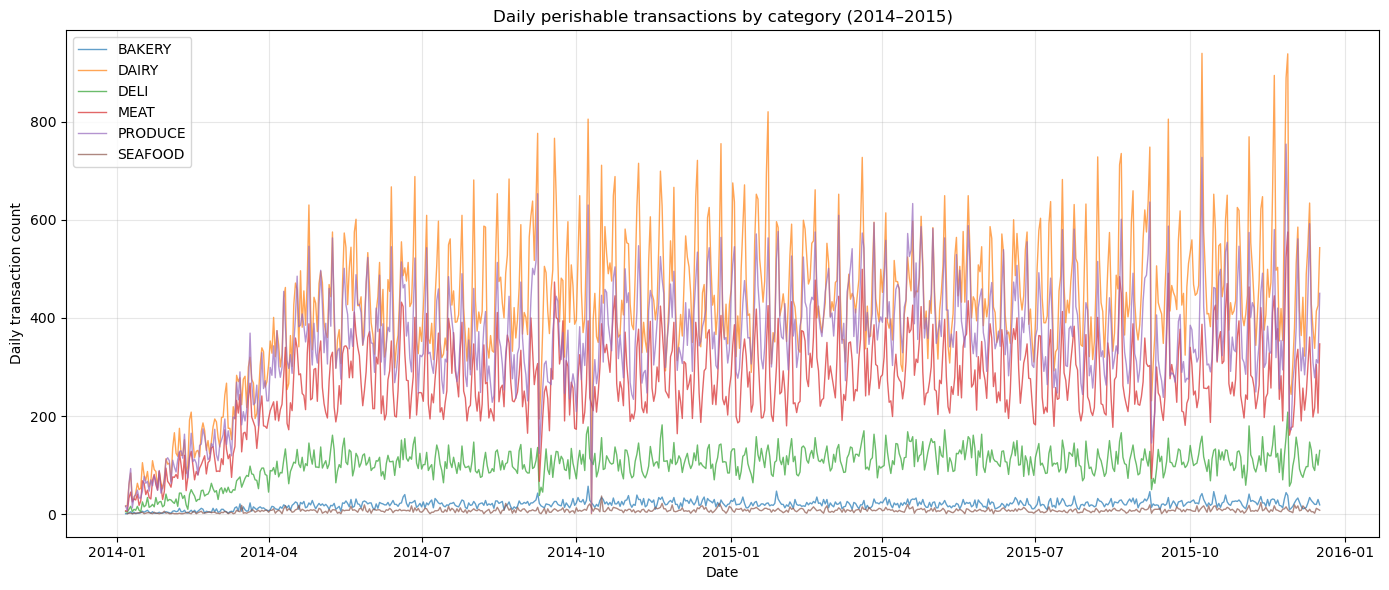

Saved plot to reports/figures/daily_txn_by_category.png


In [55]:
import matplotlib.pyplot as plt

# Daily transaction counts per category
daily_cat = transactions_perishable.groupby(["DATE", "PERISHABLE_CATEGORY"]).size().reset_index(name="txn_count")

fig, ax = plt.subplots(figsize=(14, 6))
for cat in daily_cat["PERISHABLE_CATEGORY"].unique():
    subset = daily_cat[daily_cat["PERISHABLE_CATEGORY"] == cat]
    ax.plot(subset["DATE"], subset["txn_count"], label=cat, alpha=0.7, linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("Daily transaction count")
ax.set_title("Daily perishable transactions by category (2014–2015)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
(PROJECT_ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "daily_txn_by_category.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved plot to reports/figures/daily_txn_by_category.png")


### Drop the onboarding ramp-up period

First ~90 days of dunnhumby data show progressive household/store onboarding, not real demand. Drop everything before 2014-04-06 so the model learns true demand patterns, not data collection artifacts.


In [56]:
# Define the cutoff date — drop the ramp-up period
RAMP_UP_CUTOFF = pd.Timestamp("2014-04-06")

before = len(transactions_perishable)
transactions_perishable = transactions_perishable[transactions_perishable["DATE"] >= RAMP_UP_CUTOFF].copy()
after = len(transactions_perishable)

print(f"Transactions before cutoff: {before:,}")
print(f"Transactions after cutoff:  {after:,}")
print(f"Dropped (ramp-up):          {before - after:,} ({(before-after)/before*100:.1f}%)")
print(f"\nFinal modeling date range: {transactions_perishable['DATE'].min().date()} to {transactions_perishable['DATE'].max().date()}")
print(f"Total days in modeling window: {(transactions_perishable['DATE'].max() - transactions_perishable['DATE'].min()).days + 1}")

# Re-save the cleaned file
output_path = DATA_INTERIM / "transactions_perishable.parquet"
transactions_perishable.to_parquet(output_path, index=False)
print(f"\nResaved: {output_path}")


Transactions before cutoff: 827,279
Transactions after cutoff:  784,904
Dropped (ramp-up):          42,375 (5.1%)

Final modeling date range: 2014-04-06 to 2015-12-17
Total days in modeling window: 621

Resaved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/transactions_perishable.parquet


### Verify ramp-up removed

Re-plot daily transactions per category. Lines should start at stable levels, not zero.


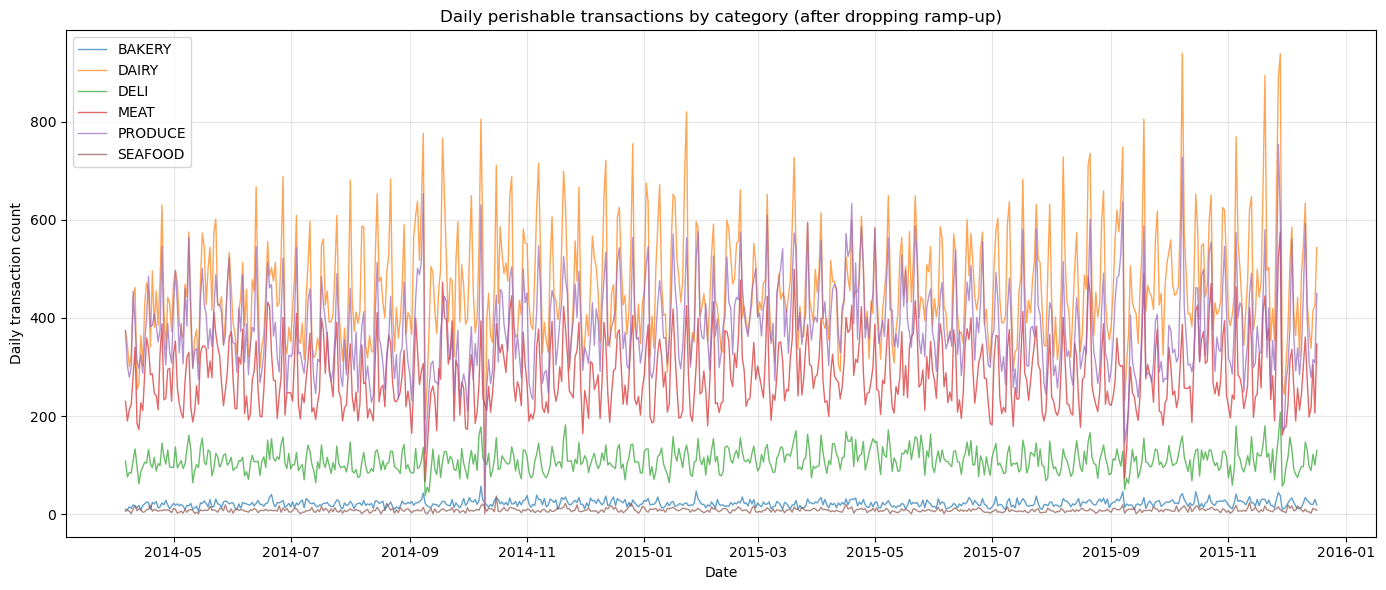

Saved plot to reports/figures/daily_txn_by_category_clean.png


In [57]:
# Re-plot with the trimmed data
daily_cat = transactions_perishable.groupby(["DATE", "PERISHABLE_CATEGORY"]).size().reset_index(name="txn_count")

fig, ax = plt.subplots(figsize=(14, 6))
for cat in daily_cat["PERISHABLE_CATEGORY"].unique():
    subset = daily_cat[daily_cat["PERISHABLE_CATEGORY"] == cat]
    ax.plot(subset["DATE"], subset["txn_count"], label=cat, alpha=0.7, linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("Daily transaction count")
ax.set_title("Daily perishable transactions by category (after dropping ramp-up)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "daily_txn_by_category_clean.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved plot to reports/figures/daily_txn_by_category_clean.png")


### Final modeling dataset summary

Numbers a reviewer will want to see: total transactions, SKUs, stores, date range, transactions per category.


In [58]:
print("=" * 60)
print("FINAL CLEANED MODELING DATASET — SUMMARY")
print("=" * 60)
print(f"Total transactions:    {len(transactions_perishable):,}")
print(f"Unique perishable SKUs: {transactions_perishable['PRODUCT_ID'].nunique():,}")
print(f"Unique stores:          {transactions_perishable['STORE_ID'].nunique():,}")
print(f"Unique households:      {transactions_perishable['household_key'].nunique():,}")
print(f"Date range:             {transactions_perishable['DATE'].min().date()} to {transactions_perishable['DATE'].max().date()}")
print(f"Total days:             {(transactions_perishable['DATE'].max() - transactions_perishable['DATE'].min()).days + 1}")
print(f"\nTransactions per category:")
for cat, count in transactions_perishable["PERISHABLE_CATEGORY"].value_counts().items():
    pct = count / len(transactions_perishable) * 100
    print(f"  {cat:10s} {count:>8,} ({pct:.1f}%)")

print(f"\nSparsity note:")
print(f"  Average transactions per SKU: {len(transactions_perishable)/transactions_perishable['PRODUCT_ID'].nunique():.1f}")
print(f"  Average transactions per (SKU, store) pair: estimating...")
sku_store_pairs = transactions_perishable.groupby(["PRODUCT_ID", "STORE_ID"]).size()
print(f"    Total SKU-store pairs: {len(sku_store_pairs):,}")
print(f"    Median transactions per pair: {sku_store_pairs.median():.0f}")
print(f"    Pairs with only 1 transaction: {(sku_store_pairs == 1).sum():,}")


FINAL CLEANED MODELING DATASET — SUMMARY
Total transactions:    784,904
Unique perishable SKUs: 13,546
Unique stores:          458
Unique households:      2,487
Date range:             2014-04-06 to 2015-12-17
Total days:             621

Transactions per category:
  DAIRY       286,981 (36.6%)
  PRODUCE     236,303 (30.1%)
  MEAT        174,855 (22.3%)
  DELI         68,149 (8.7%)
  BAKERY       13,504 (1.7%)
  SEAFOOD       5,112 (0.7%)

Sparsity note:
  Average transactions per SKU: 57.9
  Average transactions per (SKU, store) pair: estimating...
    Total SKU-store pairs: 180,486
    Median transactions per pair: 2
    Pairs with only 1 transaction: 85,535


### Cell — BDP trio sanity check

Now that the project focuses on Bakery, Dairy, Produce — verify we have enough transactions in each category for credible forecasting. Bakery was thin (1.7% of transactions); check if it's still workable.

In [59]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

txn = pd.read_parquet(DATA_INTERIM / "transactions_perishable.parquet")

bdp = txn[txn["PERISHABLE_CATEGORY"].isin(["BAKERY", "DAIRY", "PRODUCE"])]

print("BDP TRIO TRANSACTION VOLUME CHECK")
print("=" * 60)
for cat in ["BAKERY", "DAIRY", "PRODUCE"]:
    sub = bdp[bdp["PERISHABLE_CATEGORY"] == cat]
    n_skus = sub["PRODUCT_ID"].nunique()
    n_stores = sub["STORE_ID"].nunique()
    n_days = (sub["DATE"].max() - sub["DATE"].min()).days + 1
    print(f"\n{cat}:")
    print(f"  Transactions: {len(sub):,}")
    print(f"  Unique SKUs:  {n_skus:,}")
    print(f"  Unique stores: {n_stores:,}")
    print(f"  Avg transactions per (category, store, day): {len(sub) / n_stores / n_days:.2f}")
    print(f"  Avg transactions per SKU: {len(sub) / n_skus:.1f}")

print(f"\nBDP combined: {len(bdp):,} transactions ({len(bdp)/len(txn)*100:.1f}% of all perishables)")

BDP TRIO TRANSACTION VOLUME CHECK

BAKERY:
  Transactions: 13,504
  Unique SKUs:  529
  Unique stores: 184
  Avg transactions per (category, store, day): 0.12
  Avg transactions per SKU: 25.5

DAIRY:
  Transactions: 286,981
  Unique SKUs:  3,172
  Unique stores: 397
  Avg transactions per (category, store, day): 1.16
  Avg transactions per SKU: 90.5

PRODUCE:
  Transactions: 236,303
  Unique SKUs:  2,682
  Unique stores: 374
  Avg transactions per (category, store, day): 1.02
  Avg transactions per SKU: 88.1

BDP combined: 536,788 transactions (68.4% of all perishables)


### Cell — Aggregate perishable transactions to weekly grain

Markdown decisions happen weekly, not daily. Aggregating to (store, category, week) gives us cleaner signal and solves the bakery sparsity problem. Output is the modeling-ready table.

In [60]:
# Build week labels (ISO week — Monday start)
txn["WEEK_START"] = txn["DATE"] - pd.to_timedelta(txn["DATE"].dt.dayofweek, unit="d")

# Aggregate to (store, category, week)
weekly = (
    txn.groupby(["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"])
    .agg(
        units_sold=("QUANTITY", "sum"),
        sales_value=("SALES_VALUE", "sum"),
        n_transactions=("BASKET_ID", "nunique"),
        avg_price=("UNIT_PRICE", "mean"),
        n_unique_skus=("PRODUCT_ID", "nunique"),
    )
    .reset_index()
)

# Add time features
weekly["YEAR"] = weekly["WEEK_START"].dt.year
weekly["MONTH"] = weekly["WEEK_START"].dt.month
weekly["WEEK_OF_YEAR"] = weekly["WEEK_START"].dt.isocalendar().week.astype(int)

# Add BDP flag for downstream focus
weekly["IS_BDP"] = weekly["PERISHABLE_CATEGORY"].isin(["BAKERY", "DAIRY", "PRODUCE"])

print(f"Weekly aggregated rows: {len(weekly):,}")
print(f"Date range: {weekly['WEEK_START'].min().date()} to {weekly['WEEK_START'].max().date()}")
print(f"Total weeks: {weekly['WEEK_START'].nunique()}")
print(f"Stores × Categories combinations: {weekly.groupby(['STORE_ID','PERISHABLE_CATEGORY']).ngroups:,}")

print(f"\nBDP trio breakdown:")
print(weekly[weekly["IS_BDP"]].groupby("PERISHABLE_CATEGORY").agg(
    rows=("STORE_ID", "count"),
    avg_units_per_week=("units_sold", "mean"),
    median_units_per_week=("units_sold", "median"),
).to_string())

# Save
output_path = DATA_INTERIM / "weekly_perishable.parquet"
weekly.to_parquet(output_path, index=False)
print(f"\nSaved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")

Weekly aggregated rows: 50,749
Date range: 2014-03-31 to 2015-12-14
Total weeks: 90
Stores × Categories combinations: 1,706

BDP trio breakdown:
                      rows  avg_units_per_week  median_units_per_week
PERISHABLE_CATEGORY                                                  
BAKERY                6131            2.843582                    2.0
DAIRY                11042           34.606865                   31.0
PRODUCE              10624           27.827184                   23.0

Saved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/weekly_perishable.parquet
File size: 0.7 MB


### Cell — Verify store coverage across the full date range

Confirms no stores have unusually short histories that would mess up lag features. If some stores only have data for half the period, they're either new entries or closed locations — we'd need to handle them.

In [61]:
# Load the cleaned weekly data
weekly = pd.read_parquet(DATA_INTERIM / "weekly_perishable.parquet")

# How many weeks of data does each store have?
store_coverage = weekly.groupby("STORE_ID")["WEEK_START"].agg(["min", "max", "nunique"]).reset_index()
store_coverage.columns = ["STORE_ID", "first_week", "last_week", "n_weeks"]
store_coverage["span_days"] = (store_coverage["last_week"] - store_coverage["first_week"]).dt.days

print("Store coverage summary:")
print(f"  Total stores: {len(store_coverage):,}")
print(f"  Weeks of data per store:")
print(f"    Min:    {store_coverage['n_weeks'].min()}")
print(f"    Median: {store_coverage['n_weeks'].median():.0f}")
print(f"    Max:    {store_coverage['n_weeks'].max()}")

# Identify stores with limited coverage
total_weeks = weekly["WEEK_START"].nunique()
short_coverage = store_coverage[store_coverage["n_weeks"] < total_weeks * 0.75]

print(f"\nStores with <75% coverage ({total_weeks} weeks total):")
print(f"  Count: {len(short_coverage):,} ({len(short_coverage)/len(store_coverage)*100:.1f}%)")

if len(short_coverage) > 0:
    print(f"\n⚠️  Some stores have limited data. Distribution:")
    print(short_coverage["n_weeks"].describe().round(0).to_string())
    print(f"\nThe activity filter we applied (≥75% per category) should have already")
    print(f"excluded these from the modeling dataset. Verifying...")

    # Check if these stores made it into our modeled set
    modeled = pd.read_parquet(DATA_INTERIM / "features_dense.parquet")
    short_in_model = modeled[modeled["STORE_ID"].isin(short_coverage["STORE_ID"])]
    print(f"\nShort-coverage stores in final modeling set: {short_in_model['STORE_ID'].nunique():,}")
    if short_in_model['STORE_ID'].nunique() > 0:
        print(f"⚠️  These need investigation before training")
    else:
        print(f"✓ All filtered out — safe to proceed")
else:
    print(f"\n✓ All stores have ≥75% coverage — no issues")

Store coverage summary:
  Total stores: 458
  Weeks of data per store:
    Min:    1
    Median: 3
    Max:    90

Stores with <75% coverage (90 weeks total):
  Count: 351 (76.6%)

⚠️  Some stores have limited data. Distribution:
count    351.0
mean       6.0
std        9.0
min        1.0
25%        1.0
50%        2.0
75%        5.0
max       58.0

The activity filter we applied (≥75% per category) should have already
excluded these from the modeling dataset. Verifying...

Short-coverage stores in final modeling set: 0
✓ All filtered out — safe to proceed


### Cell — Verify holiday effects (updated to match new feature definition)

Tests both narrow definition (actual holiday week only) and wide definition (holiday week + pre-week). Tells us whether the expanded window captures more signal.

In [62]:
import matplotlib.pyplot as plt

# Narrow definition — actual holiday week only
HOLIDAY_NARROW = pd.to_datetime([
    "2014-11-24", "2015-11-23",   # Thanksgiving
    "2014-12-22", "2015-12-21",   # Christmas
    "2014-06-30", "2015-06-29",   # July 4
    "2014-05-26", "2015-05-25",   # Memorial Day
    "2014-09-01", "2015-09-07",   # Labor Day
    "2014-04-14", "2015-03-30",   # Easter
    "2014-12-29", "2015-12-28",   # New Year's
]).normalize()

# Wide definition — holiday week + week before
HOLIDAY_WIDE = pd.to_datetime([
    "2014-11-24", "2014-11-17", "2015-11-23", "2015-11-16",   # Thanksgiving + pre
    "2014-12-22", "2014-12-15", "2015-12-21", "2015-12-14",   # Christmas + pre
    "2014-06-30", "2014-06-23", "2015-06-29", "2015-06-22",
    "2014-05-26", "2014-05-19", "2015-05-25", "2015-05-18",
    "2014-09-01", "2014-08-25", "2015-09-07", "2015-08-31",
    "2014-04-14", "2014-04-07", "2015-03-30", "2015-03-23",
    "2014-12-29", "2015-12-28",
]).normalize()

# Load weekly data
weekly = pd.read_parquet(DATA_INTERIM / "weekly_perishable.parquet")
weekly_total = weekly.groupby("WEEK_START")["sales_value"].sum().reset_index()

# Compute lifts for both definitions
def compute_lift(holiday_weeks, label):
    weekly_total["is_holiday"] = weekly_total["WEEK_START"].isin(holiday_weeks)
    h_avg = weekly_total[weekly_total["is_holiday"]]["sales_value"].mean()
    n_avg = weekly_total[~weekly_total["is_holiday"]]["sales_value"].mean()
    lift = (h_avg - n_avg) / n_avg * 100
    print(f"\n{label}:")
    print(f"  Non-holiday avg: ${n_avg:,.0f}")
    print(f"  Holiday avg:     ${h_avg:,.0f}")
    print(f"  Lift:            {lift:+.1f}%")
    return lift

print("HOLIDAY EFFECT COMPARISON")
print("=" * 60)
lift_narrow = compute_lift(HOLIDAY_NARROW, "Narrow window (holiday week only)")
lift_wide = compute_lift(HOLIDAY_WIDE, "Wide window (holiday week + pre-week)")

# Specifically check Thanksgiving and Christmas pre-weeks (the most important)
print(f"\n\nSpecific check — December peak weeks:")
december_weeks = weekly_total[
    (weekly_total["WEEK_START"] >= "2014-12-01") & (weekly_total["WEEK_START"] <= "2014-12-31") |
    (weekly_total["WEEK_START"] >= "2015-12-01") & (weekly_total["WEEK_START"] <= "2015-12-31")
]
non_dec = weekly_total[~weekly_total["WEEK_START"].isin(december_weeks["WEEK_START"])]
dec_avg = december_weeks["sales_value"].mean()
non_dec_avg = non_dec["sales_value"].mean()
print(f"  December weeks avg:    ${dec_avg:,.0f}")
print(f"  Non-December avg:      ${non_dec_avg:,.0f}")
print(f"  December lift:         {(dec_avg - non_dec_avg) / non_dec_avg * 100:+.1f}%")

HOLIDAY EFFECT COMPARISON

Narrow window (holiday week only):
  Non-holiday avg: $25,389
  Holiday avg:     $25,619
  Lift:            +0.9%

Wide window (holiday week + pre-week):
  Non-holiday avg: $25,304
  Holiday avg:     $25,738
  Lift:            +1.7%


Specific check — December peak weeks:
  December weeks avg:    $23,875
  Non-December avg:      $25,550
  December lift:         -6.6%
